In [4]:
import pandas as pd
from datetime import timedelta

df = pd.read_csv("sales_data_sample (1).csv", encoding="latin1")
df.head()

,ORDERNUMBER,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,...,ADDRESSLINE1,ADDRESSLINE2,CITY,STATE,POSTALCODE,COUNTRY,TERRITORY,CONTACTLASTNAME,CONTACTFIRSTNAME,DEALSIZE
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [5]:
df.columns = [
    "order_number",
    "quantity_ordered",
    "price_each",
    "order_line_number",
    "sales",
    "order_date",
    "status",
    "qtr_id",
    "month_id",
    "year_id",
    "product_line",
    "msrp",
    "product_code",
    "customer_name",
    "phone",
    "address_line_1",
    "address_line_2",
    "city",
    "state",
    "postal_code",
    "country",
    "territory",
    "contact_last_name",
    "contact_first_name",
    "deal_size"
]

In [6]:
df.head()

,order_number,quantity_ordered,price_each,order_line_number,sales,order_date,status,qtr_id,month_id,year_id,...,address_line_1,address_line_2,city,state,postal_code,country,territory,contact_last_name,contact_first_name,deal_size
0,10107,30,95.70,2,2871.00,2/24/2003 0:00,Shipped,1,2,2003,...,897 Long Airport Avenue,NaN,NYC,NY,10022,USA,NaN,Yu,Kwai,Small
1,10121,34,81.35,5,2765.90,5/7/2003 0:00,Shipped,2,5,2003,...,59 rue de l'Abbaye,NaN,Reims,NaN,51100,France,EMEA,Henriot,Paul,Small
2,10134,41,94.74,2,3884.34,7/1/2003 0:00,Shipped,3,7,2003,...,27 rue du Colonel Pierre Avia,NaN,Paris,NaN,75508,France,EMEA,Da Cunha,Daniel,Medium
3,10145,45,83.26,6,3746.70,8/25/2003 0:00,Shipped,3,8,2003,...,78934 Hillside Dr.,NaN,Pasadena,CA,90003,USA,NaN,Young,Julie,Medium
4,10159,49,100.00,14,5205.27,10/10/2003 0:00,Shipped,4,10,2003,...,7734 Strong St.,NaN,San Francisco,CA,NaN,USA,NaN,Brown,Julie,Medium


In [8]:
df.shape

(2823, 25)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_number        2823 non-null   int64  
 1   quantity_ordered    2823 non-null   int64  
 2   price_each          2823 non-null   float64
 3   order_line_number   2823 non-null   int64  
 4   sales               2823 non-null   float64
 5   order_date          2823 non-null   object 
 6   status              2823 non-null   object 
 7   qtr_id              2823 non-null   int64  
 8   month_id            2823 non-null   int64  
 9   year_id             2823 non-null   int64  
 10  product_line        2823 non-null   object 
 11  msrp                2823 non-null   int64  
 12  product_code        2823 non-null   object 
 13  customer_name       2823 non-null   object 
 14  phone               2823 non-null   object 
 15  address_line_1      2823 non-null   object 
 16  addres

In [10]:
df.isna().sum()

order_number             0
quantity_ordered         0
price_each               0
order_line_number        0
sales                    0
order_date               0
status                   0
qtr_id                   0
month_id                 0
year_id                  0
product_line             0
msrp                     0
product_code             0
customer_name            0
phone                    0
address_line_1           0
address_line_2        2521
city                     0
state                 1486
postal_code             76
country                  0
territory             1074
contact_last_name        0
contact_first_name       0
deal_size                0
dtype: int64

In [12]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing[missing["missing_count"] > 0].sort_values(
    "missing_count",
    ascending=False
)

,missing_count,missing_percent
address_line_2,2521,89.302161
state,1486,52.639036
territory,1074,38.044633
postal_code,76,2.692171


In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [14]:
df["order_date"].dtype

dtype('<M8[ns]')

In [15]:
from datetime import timedelta
reference_date = df["order_date"].max() + timedelta(days=1)
reference_date

Timestamp('2005-06-01 00:00:00')

In [16]:
rfm = df.groupby("customer_name").agg(
    recency=("order_date", lambda x: (reference_date - x.max()).days),
    frequency=("order_number", "nunique"),
    monetary=("sales", "sum")
).reset_index()

In [17]:
rfm.head()

,customer_name,recency,frequency,monetary
0,"AV Stores, Co.",196,3,157807.81
1,Alpha Cognac,65,3,70488.44
2,Amica Models & Co.,265,2,94117.26
3,"Anna's Decorations, Ltd",84,4,153996.13
4,Atelier graphique,188,3,24179.96


In [18]:
rfm.shape

(92, 4)

In [19]:
rfm["r_score"] = pd.qcut(
    rfm["recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

In [20]:
rfm["f_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [21]:
rfm["m_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

In [23]:
rfm.head(10)

,customer_name,recency,frequency,monetary,r_score,f_score,m_score
0,"AV Stores, Co.",196,3,157807.81,2,2,4
1,Alpha Cognac,65,3,70488.44,4,2,2
2,Amica Models & Co.,265,2,94117.26,1,1,3
3,"Anna's Decorations, Ltd",84,4,153996.13,3,4,4
4,Atelier graphique,188,3,24179.96,2,2,1
5,"Australian Collectables, Ltd",23,3,64591.46,4,2,1
6,"Australian Collectors, Co.",184,5,200995.41,3,4,4
7,"Australian Gift Network, Co",119,3,59469.12,3,2,1
8,Auto Assoc. & Cie.,233,2,64834.32,1,1,1
9,Auto Canal Petit,55,3,93170.66,4,2,3


In [24]:
rfm["rfm_segment"] = (
    rfm[["r_score", "f_score", "m_score"]]
    .astype(str)
    .agg("".join, axis=1)
)

In [25]:
rfm[["customer_name", "r_score", "f_score", "m_score", "rfm_segment"]].head(10)

,customer_name,r_score,f_score,m_score,rfm_segment
0,"AV Stores, Co.",2,2,4,224
1,Alpha Cognac,4,2,2,422
2,Amica Models & Co.,1,1,3,113
3,"Anna's Decorations, Ltd",3,4,4,344
4,Atelier graphique,2,2,1,221
5,"Australian Collectables, Ltd",4,2,1,421
6,"Australian Collectors, Co.",3,4,4,344
7,"Australian Gift Network, Co",3,2,1,321
8,Auto Assoc. & Cie.,1,1,1,111
9,Auto Canal Petit,4,2,3,423


In [55]:
def assign_segment(row):
    r = row["r_score"]
    f = row["f_score"]
    m = row["m_score"]

    if r == 4 and f == 4 and m == 4:
        return "Champions"

    elif r == 1 and f >= 3 and m >= 3:
        return "At Risk"

    elif r == 1 and f == 1 and m == 1:
        return "Lost"

    elif r >= 3 and f >= 3 and m >= 3:
        return "Loyal"

    else:
        return "Needs Attention"

In [56]:
rfm["segment"] = rfm.apply(assign_segment, axis=1)

In [58]:
rfm["segment"].value_counts()

segment
Needs Attention    54
Loyal              17
Lost               11
Champions           9
At Risk             1
Name: count, dtype: int64

In [59]:
segment_summary = rfm.groupby("segment").agg(
    customer_count=("customer_name", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).reset_index()

segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary
0,At Risk,1,456.000000,3.000000,142874.250000
1,Champions,9,19.444444,8.111111,290097.736667
2,Lost,11,360.454545,1.909091,52366.990909
3,Loyal,17,110.294118,3.588235,132894.919412
4,Needs Attention,54,191.648148,2.759259,82289.341481


In [81]:
rfm["frequency"].describe().round(2)

count    92.00
mean      3.34
std       2.92
min       1.00
25%       2.00
50%       3.00
75%       3.00
max      26.00
Name: frequency, dtype: float64

In [82]:
rfm["monetary"].describe().round(2)

count        92.00
mean     109050.31
std      110308.61
min        9129.35
25%       70129.43
50%       86522.61
75%      120575.88
max      912294.11
Name: monetary, dtype: float64

In [83]:
rfm["recency"].describe().round(2)

count     92.00
mean     182.83
std      131.42
min        1.00
25%       81.25
50%      186.00
75%      230.25
max      509.00
Name: recency, dtype: float64

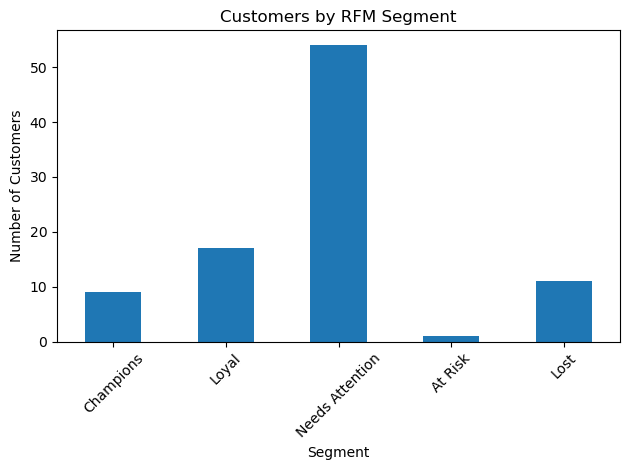

In [60]:
segment_order = [
    "Champions",
    "Loyal",
    "Needs Attention",
    "At Risk",
    "Lost"
]

segment_counts = (
    rfm["segment"]
    .value_counts()
    .reindex(segment_order)
)

segment_counts.plot(kind="bar")

plt.title("Customers by RFM Segment")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "rfm_segment_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding — Customer Segment Distribution

The largest customer segment is **Needs Attention**, with 54 customers. This indicates that most customers show moderate or mixed purchasing behavior and may benefit from targeted engagement campaigns.

**Loyal** customers account for 17 customers, while **Champions** include 9 high-value customers. **Lost** customers represent 11 customers, and only 1 customer is classified as **At Risk**.

The results suggest that the largest opportunity is to improve engagement among the Needs Attention group while retaining Champions and Loyal customers.

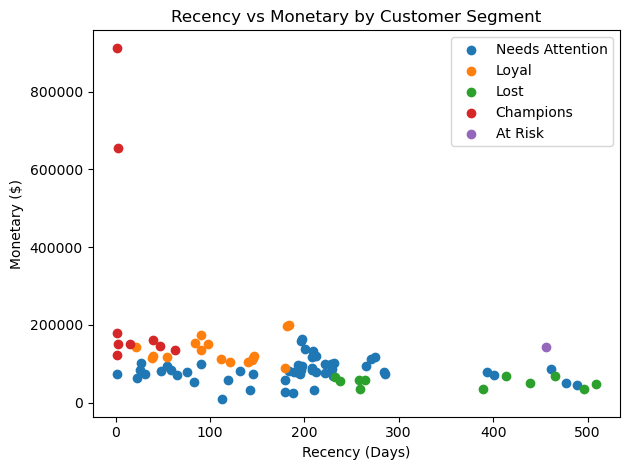

In [61]:
segments = rfm["segment"].unique()

for segment in segments:
    data = rfm[rfm["segment"] == segment]
    plt.scatter(
        data["recency"],
        data["monetary"],
        label=segment
    )

plt.title("Recency vs Monetary by Customer Segment")
plt.xlabel("Recency (Days)")
plt.ylabel("Monetary ($)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "recency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding — Recency vs Monetary

The Recency vs Monetary plot shows that **Champions** are generally among the most recent and highest-value customers.

Several Champion customers have particularly high monetary values, indicating a small group of customers that contributes substantially to overall sales.

Customers with high Recency values are less recently active, which makes them potential targets for retention or reactivation campaigns depending on their Frequency and Monetary scores.

In [62]:
rfm[rfm["segment"] == "Champions"][
    ["customer_name", "recency", "frequency", "monetary", "rfm_segment"]
].sort_values("monetary", ascending=False)

,customer_name,recency,frequency,monetary,rfm_segment
33,Euro Shopping Channel,1,26,912294.11,444
55,Mini Gifts Distributors Ltd.,3,17,654858.06,444
44,La Rochelle Gifts,1,4,180124.90,444
81,The Sharp Gifts Warehouse,40,4,160010.27,444
75,Souveniers And Things Co.,3,4,151570.98,444
70,Salzburg Collectables,15,4,149798.63,444
27,Danish Wholesale Imports,47,5,145041.60,444
66,Reims Collectables,63,5,135042.94,444
28,Diecast Classics Inc.,2,4,122138.14,444


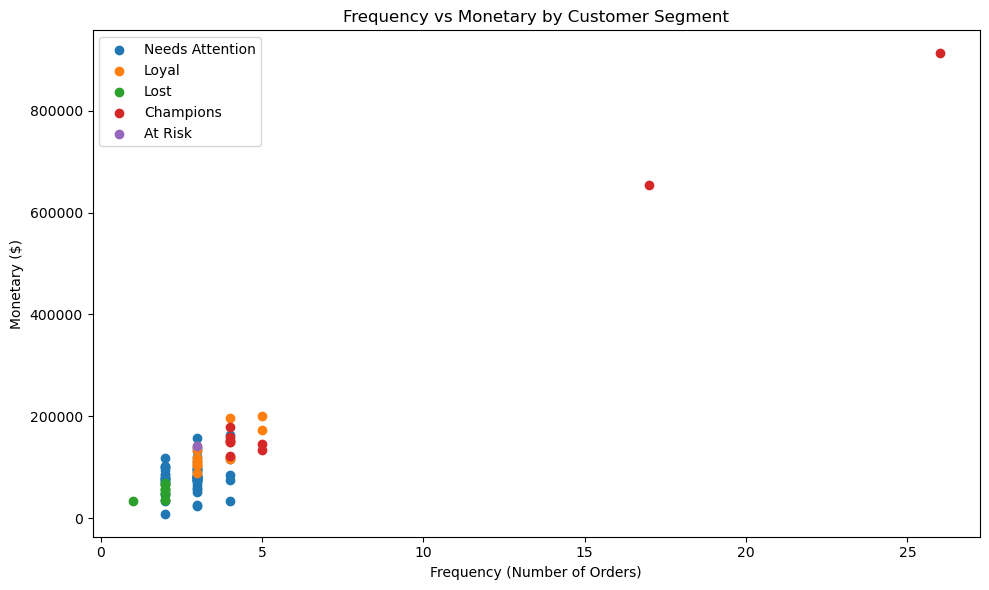

In [63]:
plt.figure(figsize=(10, 6))

for segment in rfm["segment"].unique():
    data = rfm[rfm["segment"] == segment]
    
    plt.scatter(
        data["frequency"],
        data["monetary"],
        label=segment
    )

plt.title("Frequency vs Monetary by Customer Segment")
plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Monetary ($)")
plt.legend()
plt.tight_layout()

plt.savefig(
    "frequency_vs_monetary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding — Frequency vs Monetary

The Frequency vs Monetary plot shows that customers with more orders generally tend to generate higher total sales.

The **Champions** segment contains several high-frequency and high-monetary customers, while **Lost** customers generally have lower purchasing frequency and monetary value.

This highlights the importance of encouraging repeat purchases and increasing customer engagement over time.

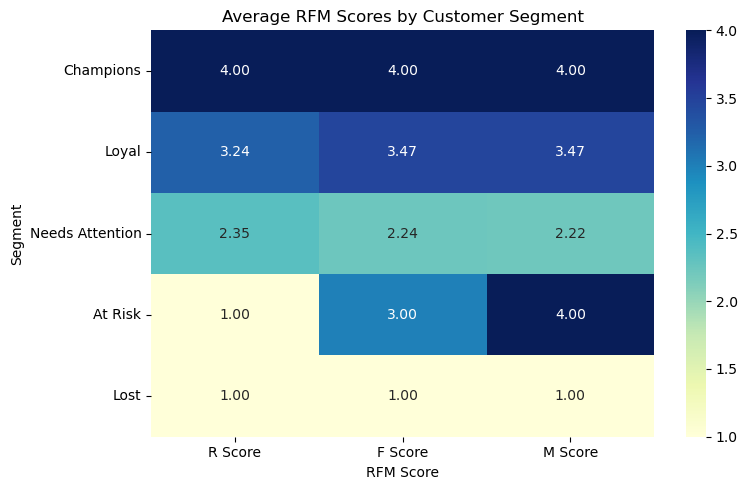

In [64]:
score_summary = rfm.groupby("segment")[
    ["r_score", "f_score", "m_score"]
].mean()

score_summary = score_summary.reindex([
    "Champions",
    "Loyal",
    "Needs Attention",
    "At Risk",
    "Lost"
])

score_summary.columns = ["R Score", "F Score", "M Score"]

plt.figure(figsize=(8, 5))

sns.heatmap(
    score_summary,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=1,
    vmax=4
)

plt.title("Average RFM Scores by Customer Segment")
plt.xlabel("RFM Score")
plt.ylabel("Segment")
plt.tight_layout()

plt.savefig(
    "rfm_score_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding — Average RFM Scores by Segment

The heatmap clearly differentiates the customer segments based on their average RFM scores.

**Champions** have the strongest combination of Recency, Frequency, and Monetary scores. **Loyal** customers also show relatively strong RFM behavior.

**Lost** customers have low scores across all three dimensions, while **At Risk** customers have low Recency but relatively stronger Frequency and Monetary scores, indicating previously valuable customers who have become inactive.

The **Needs Attention** segment falls between these groups and represents the largest opportunity for targeted engagement.

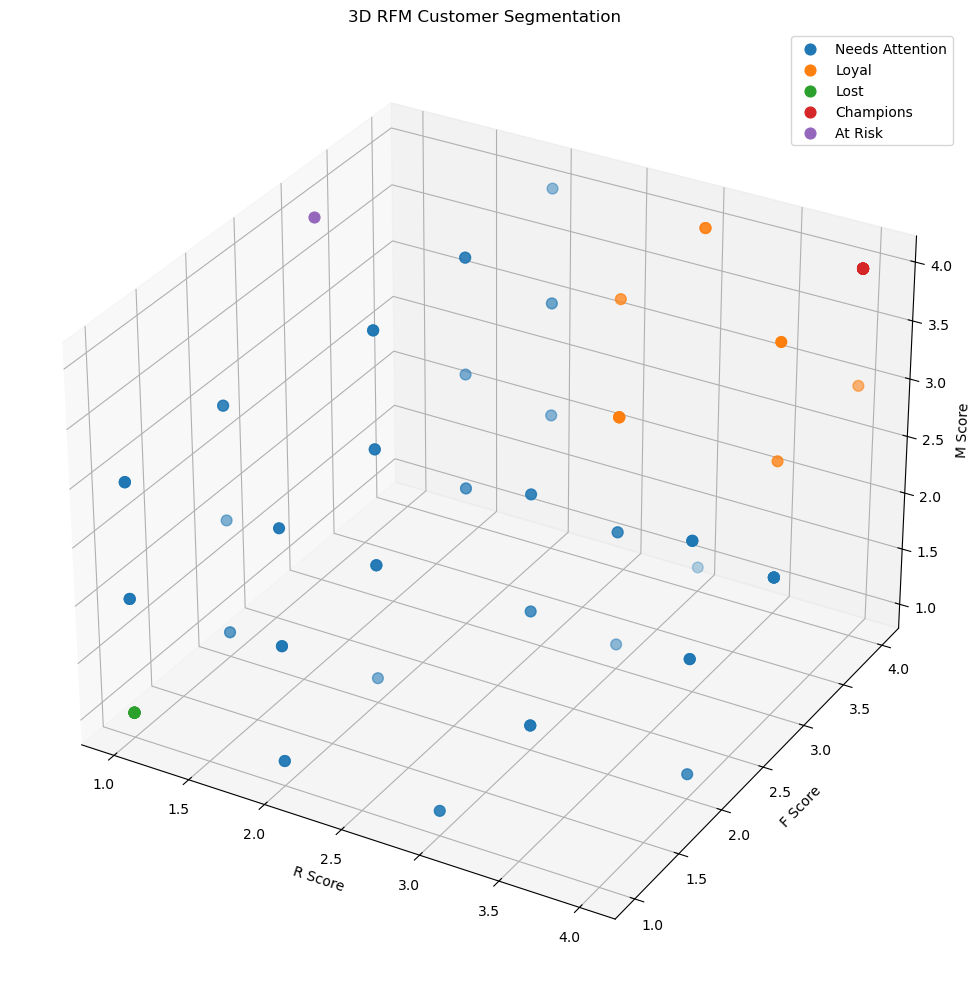

In [65]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection="3d")

segments = rfm["segment"].unique()

for segment in segments:
    data = rfm[rfm["segment"] == segment]
    
    ax.scatter(
        data["r_score"],
        data["f_score"],
        data["m_score"],
        label=segment,
        s=60
    )

ax.set_title("3D RFM Customer Segmentation")
ax.set_xlabel("R Score")
ax.set_ylabel("F Score")
ax.set_zlabel("M Score")

ax.legend()

plt.tight_layout()

plt.savefig(
    "rfm_3d_segmentation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Key Finding — 3D RFM Segmentation

The 3D visualization provides an overall view of how customers are distributed across Recency, Frequency, and Monetary dimensions.

The visualization highlights the separation between high-value active customers, moderately engaged customers, and inactive customers.

This supports the rule-based segmentation and provides an intuitive view of the different customer profiles.

In [72]:
segment_summary = rfm.groupby("segment").agg(
    customer_count=("customer_name", "count"),
    avg_recency=("recency", "mean"),
    avg_frequency=("frequency", "mean"),
    avg_monetary=("monetary", "mean")
).reset_index()

segment_order = [
    "Champions",
    "Loyal",
    "Needs Attention",
    "At Risk",
    "Lost"
]

segment_summary["segment"] = pd.Categorical(
    segment_summary["segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = segment_summary.sort_values("segment")

segment_summary[[
    "avg_recency",
    "avg_frequency",
    "avg_monetary"
]] = segment_summary[[
    "avg_recency",
    "avg_frequency",
    "avg_monetary"
]].round(2)

segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary
1,Champions,9,19.44,8.11,290097.74
3,Loyal,17,110.29,3.59,132894.92
4,Needs Attention,54,191.65,2.76,82289.34
0,At Risk,1,456.00,3.00,142874.25
2,Lost,11,360.45,1.91,52366.99


In [74]:
marketing_strategy = {
    "Champions": "VIP rewards, exclusive offers, early access, and premium loyalty benefits",
    
    "Loyal": "Loyalty program, personalized offers, cross-selling, and repeat-purchase incentives",
    
    "Needs Attention": "Personalized discounts, product recommendations, reminder campaigns, and engagement offers",
    
    "At Risk": "Urgent win-back campaign, special discount, personalized email, and limited-time incentive",
    
    "Lost": "Reactivation campaign, strong comeback offer, personalized email, and targeted promotions"
}

segment_summary["marketing_strategy"] = (
    segment_summary["segment"]
    .astype(str)
    .map(marketing_strategy)
)

segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary,marketing_strategy
1,Champions,9,19.44,8.11,290097.74,"VIP rewards, exclusive offers, early access, a..."
3,Loyal,17,110.29,3.59,132894.92,"Loyalty program, personalized offers, cross-se..."
4,Needs Attention,54,191.65,2.76,82289.34,"Personalized discounts, product recommendation..."
0,At Risk,1,456.00,3.00,142874.25,"Urgent win-back campaign, special discount, pe..."
2,Lost,11,360.45,1.91,52366.99,"Reactivation campaign, strong comeback offer, ..."


In [78]:
rfm.to_csv("rfm_customer_report.csv", index=False)

In [79]:
segment_summary.to_csv("rfm_segment_summary.csv", index=False)

In [77]:
rfm.shape
segment_summary

,segment,customer_count,avg_recency,avg_frequency,avg_monetary,marketing_strategy
1,Champions,9,19.44,8.11,290097.74,"VIP rewards, exclusive offers, early access, a..."
3,Loyal,17,110.29,3.59,132894.92,"Loyalty program, personalized offers, cross-se..."
4,Needs Attention,54,191.65,2.76,82289.34,"Personalized discounts, product recommendation..."
0,At Risk,1,456.00,3.00,142874.25,"Urgent win-back campaign, special discount, pe..."
2,Lost,11,360.45,1.91,52366.99,"Reactivation campaign, strong comeback offer, ..."


## Final Insights

The RFM analysis identified five customer segments across 92 customers.

- **Champions:** 9 customers — highest-value and most recently active customers.
- **Loyal:** 17 customers — customers with strong and consistent purchasing behavior.
- **Needs Attention:** 54 customers — the largest group and the main opportunity for engagement.
- **At Risk:** 1 customer — previously valuable but currently inactive.
- **Lost:** 11 customers — inactive customers with low overall RFM scores.

The analysis suggests prioritizing **retention for Champions and Loyal customers**, **engagement for Needs Attention customers**, and **win-back or reactivation campaigns for At Risk and Lost customers**.